# Final Project Results

## GCN Baseline

In [17]:
import sys
from pathlib import Path

# Allows importing from the project root
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))


Imports

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.gcn_baseline import run_experiment


Pick dataset

In [19]:
dataset_name = "Cora"  # "CiteSeer" or "Cora"

if dataset_name.lower() == "citeseer":
    dataset_name = "CiteSeer"

dataset_name


'Cora'

Run the GCN experiment

In [20]:
model, dataset, data, results = run_experiment(dataset_name, epochs=200)

run_path = Path(results["run_dir"])
plot_path = Path(results["plot_dir"])
losses = results["losses"]
val_accuracies = results["val_accuracies"]

model


Dataset: Cora
Nodes: 2708
Edges: 10556
Features per node: 1433
Classes: 7
Train nodes: 140
Validation nodes: 500
Test nodes: 1000
Epoch: 1 Loss: 1.9453 Val acc: 0.244
Epoch: 20 Loss: 1.7003 Val acc: 0.748
Epoch: 40 Loss: 1.2521 Val acc: 0.772
Epoch: 60 Loss: 0.8768 Val acc: 0.792
Epoch: 80 Loss: 0.6418 Val acc: 0.798
Epoch: 100 Loss: 0.5218 Val acc: 0.792
Epoch: 120 Loss: 0.4222 Val acc: 0.794
Epoch: 140 Loss: 0.3943 Val acc: 0.794
Epoch: 160 Loss: 0.3643 Val acc: 0.792
Epoch: 180 Loss: 0.3474 Val acc: 0.794
Epoch: 200 Loss: 0.2589 Val acc: 0.79

Final results:
Train accuracy: 1.0
Validation accuracy: 0.79
Test accuracy: 0.823
Macro F1: 0.8134
Weighted F1: 0.8244
Saved run to: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\runs\gcn\20260502_154450_Cora_GCN
Plots go to: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\plots\gcn\20260502_154450_Cora_GCN


GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)

Tables

In [21]:
dataset_table = pd.DataFrame([
    {
        "Dataset": dataset.name,
        "Nodes": data.num_nodes,
        "Edges": data.num_edges,
        "Avg Degree": data.num_edges / data.num_nodes,
        "Density": data.num_edges / (data.num_nodes * (data.num_nodes - 1)),
        "Features": dataset.num_node_features,
        "Classes": dataset.num_classes,
        "Train": int(data.train_mask.sum()),
        "Val": int(data.val_mask.sum()),
        "Test": int(data.test_mask.sum()),
    }
])

main_results_table = pd.DataFrame([
    {
        "Dataset": dataset.name,
        "Model": "GCN",
        "Train Acc": results["train_acc"],
        "Val Acc": results["val_acc"],
        "Test Acc": results["test_acc"],
        "Macro F1": results["macro_f1"],
        "Weighted F1": results["weighted_f1"],
    }
])

model_table = pd.DataFrame([
    {
        "Model": "GCN",
        "Hidden Size": 16,
        "Epochs": 200,
        "Learning Rate": 0.01,
        "Weight Decay": 0.0005,
        "Parameters": results["parameters"],
    }
])

print("Dataset Table")
display(dataset_table.round(4))

print("Main Results Table")
display(main_results_table.round(4))

print("Model Table")
display(model_table)

print("Run folder:", run_path)
print("Plot folder:", plot_path)


Dataset Table


,Dataset,Nodes,Edges,Avg Degree,Density,Features,Classes,Train,Val,Test
0,Cora,2708,10556,3.8981,0.0014,1433,7,140,500,1000


Main Results Table


,Dataset,Model,Train Acc,Val Acc,Test Acc,Macro F1,Weighted F1
0,Cora,GCN,1.0,0.79,0.823,0.8134,0.8244


Model Table


,Model,Hidden Size,Epochs,Learning Rate,Weight Decay,Parameters
0,GCN,16,200,0.01,0.0005,23063


Run folder: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\runs\gcn\20260502_154450_Cora_GCN
Plot folder: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\plots\gcn\20260502_154450_Cora_GCN


Per-class metrics

In [22]:
per_class_table = pd.DataFrame(results["per_class_metrics"])

print("Per-class Test Metrics")
display(per_class_table.round(4))


Per-class Test Metrics


,class,precision,recall,f1,support
0,0,0.6871,0.7769,0.7292,130
1,1,0.7879,0.8571,0.8211,91
2,2,0.8750,0.8750,0.8750,144
3,3,0.9107,0.7994,0.8514,319
4,4,0.7952,0.8859,0.8381,149
5,5,0.8837,0.7379,0.8042,103
6,6,0.7051,0.8594,0.7746,64


Training plots

Saved: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\plots\gcn\20260502_154450_Cora_GCN\training_curves.png


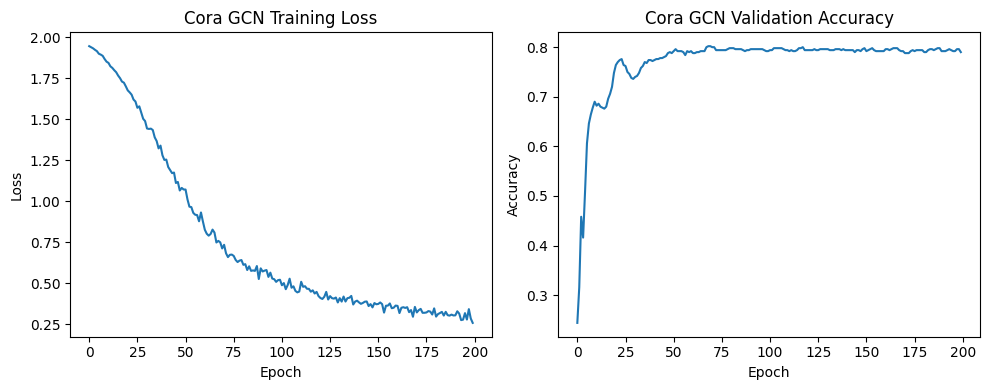

In [23]:
training_plot = plot_path / "training_curves.png"

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title(dataset_name + " GCN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title(dataset_name + " GCN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig(training_plot, dpi=150, bbox_inches="tight")
print("Saved:", training_plot)
plt.show()


Confusion matrix

Saved: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\plots\gcn\20260502_154450_Cora_GCN\confusion_matrix.png


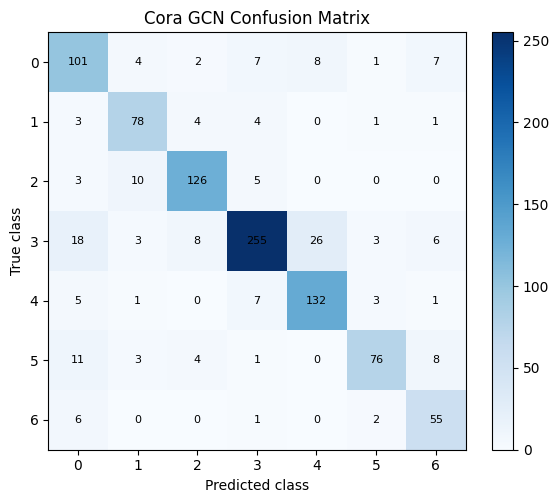

In [24]:
confusion_plot = plot_path / "confusion_matrix.png"
confusion = results["confusion_matrix"]

plt.figure(figsize=(6, 5))
plt.imshow(confusion, cmap="Blues")
plt.title(dataset_name + " GCN Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()

for i in range(len(confusion)):
    for j in range(len(confusion[i])):
        plt.text(j, i, confusion[i][j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(confusion_plot, dpi=150, bbox_inches="tight")
print("Saved:", confusion_plot)
plt.show()
